## Importando bibliotecas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configuração para exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)

### carregar dataset

In [12]:
df = pd.read_csv("../data/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [13]:
# Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [14]:
# Estatísticas das variáveis numéricas
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


A maior parte dos clientes é relativamente jovem.
Credit amount - Isso sugere uma distribuição assimétrica à direita, indicando que alguns clientes solicitaram empréstimos muito superiores à maioria.
job - Mesmo armazenada como número, ela é uma variável categórica ordinal.

In [15]:
# Estatísticas das variáveis categóricas
df.describe(include="object")

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


In [16]:
Há predominancia masculina
muitos clientes possuem casa própria.
Isso indica que boa parte dos empréstimos foi destinada à compra de veículos.

SyntaxError: invalid syntax (2062626328.py, line 1)

In [17]:
# Lista todas as colunas
df.columns.tolist()

['Unnamed: 0',
 'Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

### EDA

In [18]:
# Quantidade de valores ausentes por coluna
missing_values = df.isnull().sum()

# Percentual de valores ausentes
missing_percent = (df.isnull().sum() / len(df)) * 100

# Cria uma tabela resumindo a quantidade e o percentual
missing_table = pd.DataFrame({
    'Valores Ausentes': missing_values,
    'Percentual (%)': missing_percent
})

# Ordena da maior para a menor quantidade de valores ausentes
missing_table = missing_table.sort_values(
    by='Percentual (%)',
    ascending=False
)

missing_table

,Valores Ausentes,Percentual (%)
Checking account,394,39.4
Saving accounts,183,18.3
Unnamed: 0,0,0.0
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


In [19]:
# Verifica a quantidade de linhas duplicadas
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


In [20]:
for coluna in df.select_dtypes(include="object").columns:
    print(f"\n{coluna}")
    print(df[coluna].value_counts(dropna=False))


Sex
Sex
male      690
female    310
Name: count, dtype: int64

Housing
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

Saving accounts
Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Checking account
Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Risk
Risk
good    700
bad     300
Name: count, dtype: int64


In [21]:
# Conta quantas observações existem em cada classe
risk_counts = df["Risk"].value_counts()

risk_counts

Risk
good    700
bad     300
Name: count, dtype: int64

In [22]:
# Calcula o percentual de cada classe
risk_percentage = (
    df["Risk"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

risk_percentage

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

In [23]:
# Cria uma tabela resumindo quantidade e percentual
risk_summary = pd.DataFrame({
    "Quantidade": risk_counts,
    "Percentual (%)": risk_percentage
})

risk_summary

,Quantidade,Percentual (%)
Risk,,
good,700,70.0
bad,300,30.0


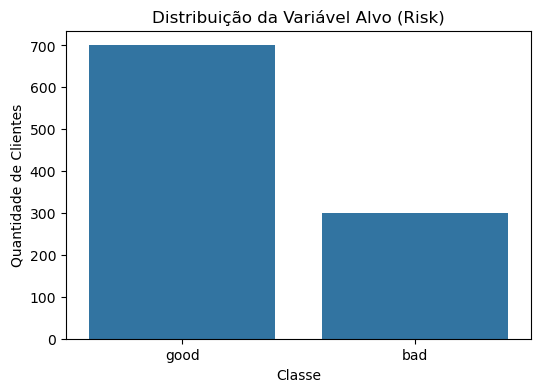

In [24]:
# Configuração do tamanho da figura
plt.figure(figsize=(6,4))

# Gráfico de barras
sns.countplot(
    data=df,
    x="Risk"
)

plt.title("Distribuição da Variável Alvo (Risk)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Clientes")

plt.show()

A análise da variável alvo revelou uma distribuição de 70% de clientes classificados como bons pagadores e 30% como maus pagadores. Apesar de representar um desbalanceamento moderado, a proporção da classe de interesse é suficiente para permitir o aprendizado de padrões pelo modelo. Entretanto, devido ao contexto de risco de crédito, a avaliação do modelo não poderá depender apenas da acurácia, sendo necessário analisar métricas capazes de medir a identificação correta dos clientes inadimplentes, como Recall, F1-score e ROC-AUC.

In [25]:
df["Age"].skew()

np.float64(1.0207392686768317)

In [26]:
df["Age"].kurt()

np.float64(0.5957795670766881)

In [27]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [28]:
# Estatísticas das variáveis numéricas
numeric_cols = ["Age", "Credit amount", "Duration"]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


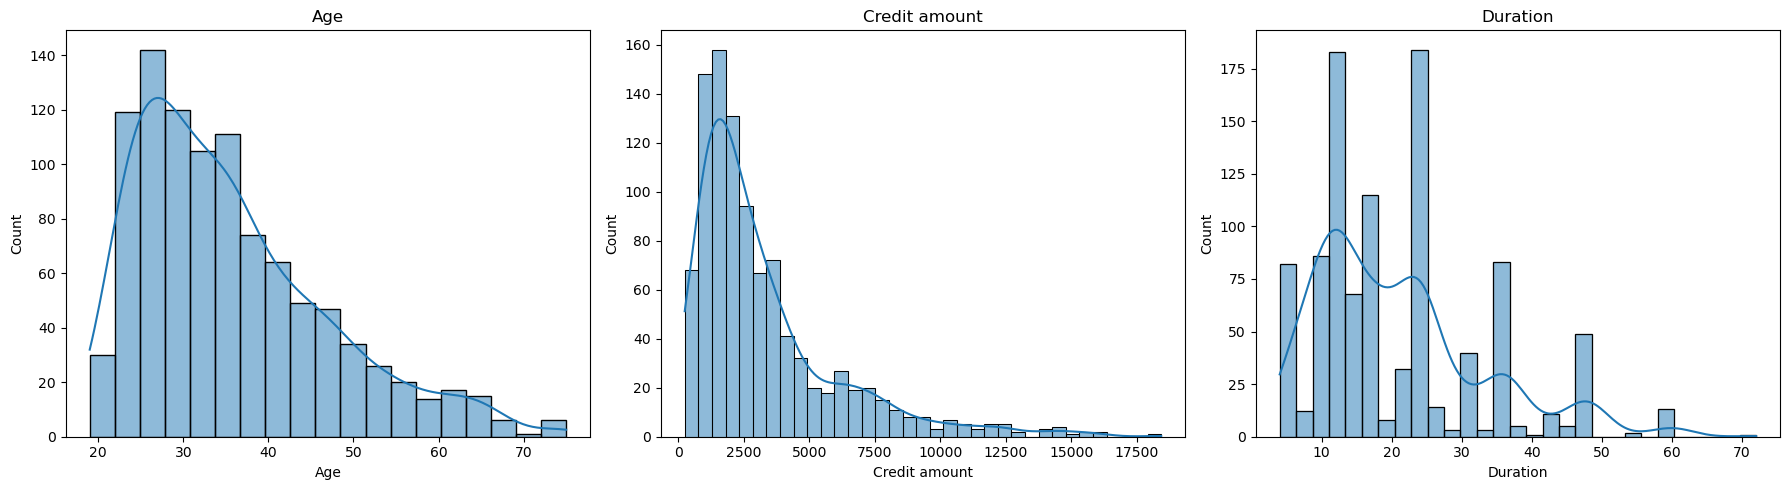

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Age", "Credit amount", "Duration"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

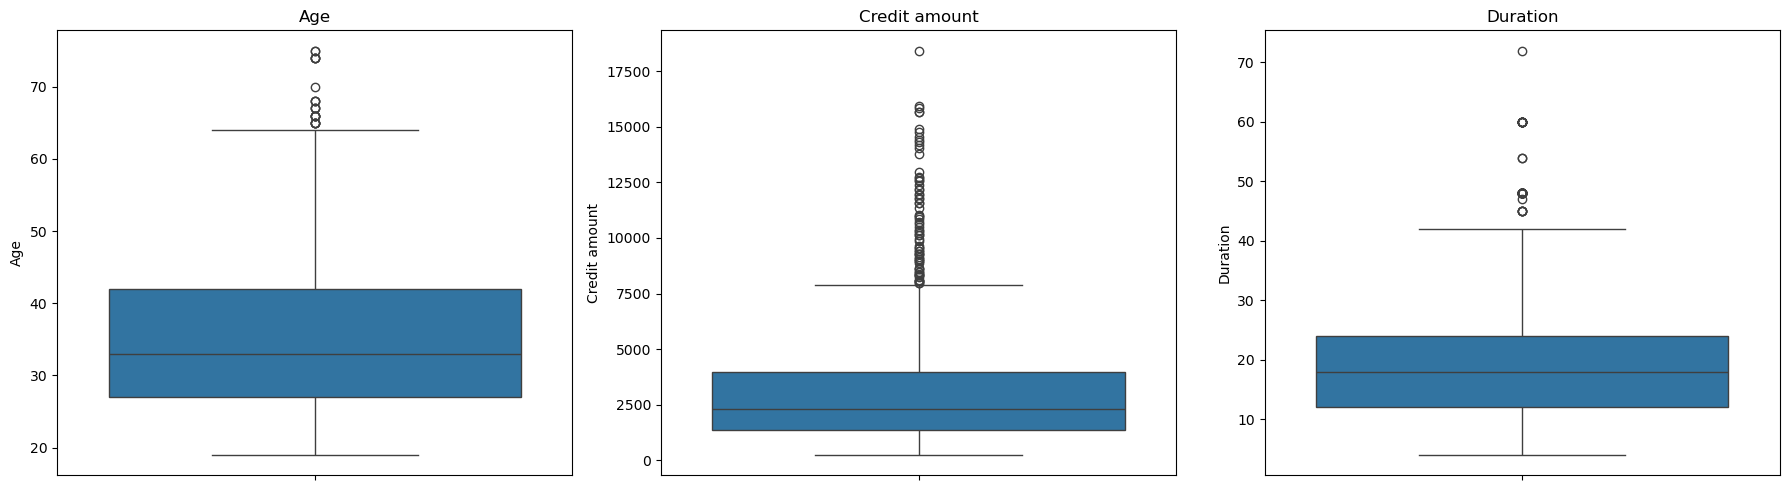

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [31]:
summary = pd.DataFrame({
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})

summary

,Skewness,Kurtosis
Age,1.020739,0.595780
Credit amount,1.949628,4.292590
Duration,1.094184,0.919781


Age                              Credit amount                   \
     count   mean median    std min max         count     mean  median   
Risk                                                                     
bad    300  33.96   31.0  11.22  19  74           300  3938.13  2574.5   
good   700  36.22   34.0  11.38  19  75           700  2985.46  2244.0   

                          Duration                               
          std  min    max    count   mean median    std min max  
Risk                                                             
bad   3535.82  433  18424      300  24.86   24.0  13.28   6  72  
good  2401.47  250  15857      700  19.21   18.0  11.08   4  60

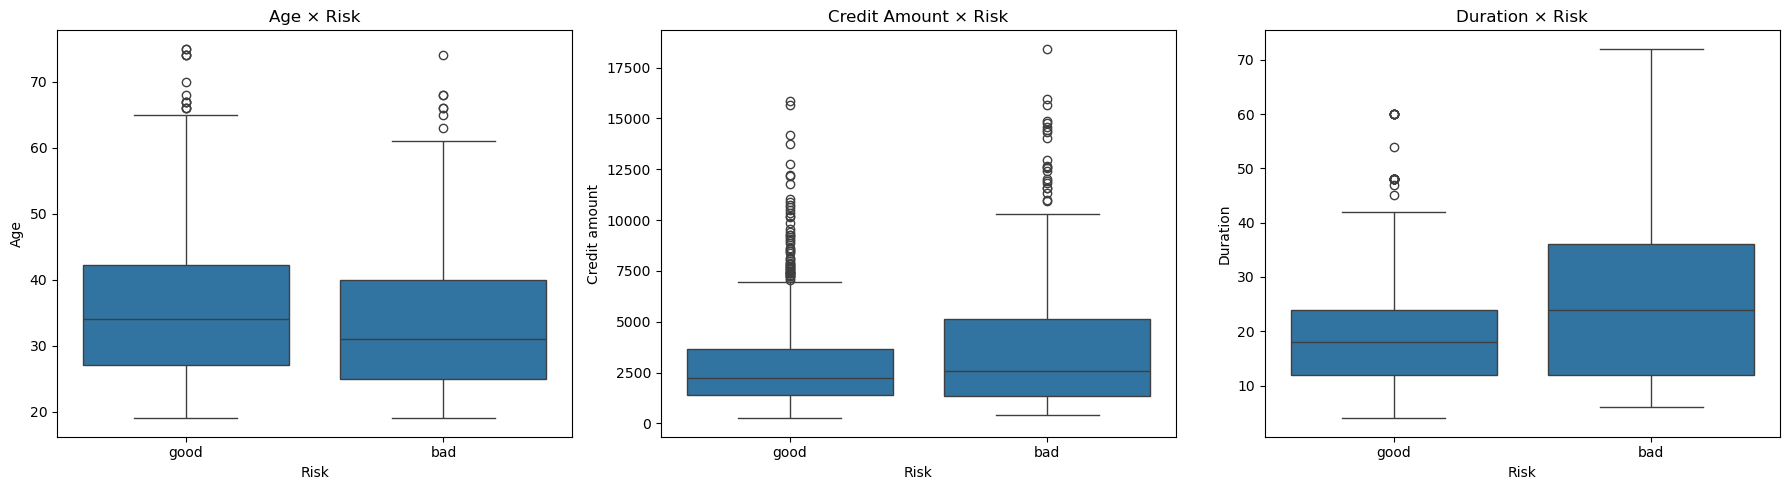

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Estatísticas por classe
# -----------------------------
display(
    df.groupby("Risk")[["Age", "Credit amount", "Duration"]]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

# -----------------------------
# Boxplots
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=df, x="Risk", y="Age", ax=axes[0])
axes[0].set_title("Age × Risk")

sns.boxplot(data=df, x="Risk", y="Credit amount", ax=axes[1])
axes[1].set_title("Credit Amount × Risk")

sns.boxplot(data=df, x="Risk", y="Duration", ax=axes[2])
axes[2].set_title("Duration × Risk")

plt.tight_layout()
plt.show()



A análise bivariada indicou que Duration e Credit amount apresentam maior relação com o risco de crédito, enquanto Age possui menor diferenciação entre as classes. Todas as variáveis serão mantidas para que a Random Forest capture seus efeitos combinados.


Sex


Risk,bad,good,All
Sex,,,
female,109,201,310
male,191,499,690
All,300,700,1000


Risk,bad,good
Sex,,
female,35.2,64.8
male,27.7,72.3


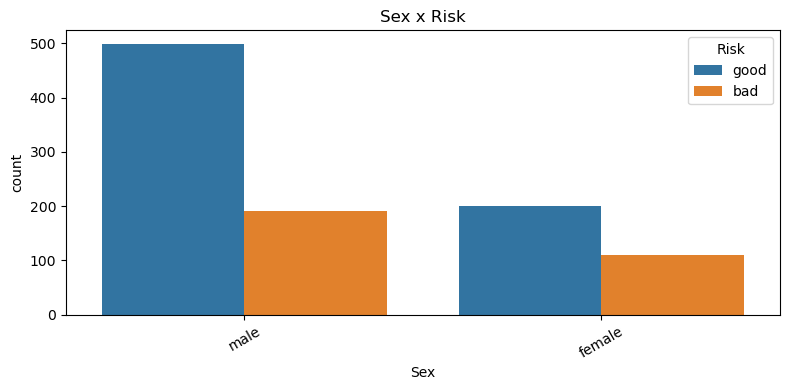


Housing


Risk,bad,good,All
Housing,,,
free,44,64,108
own,186,527,713
rent,70,109,179
All,300,700,1000


Risk,bad,good
Housing,,
free,40.7,59.3
own,26.1,73.9
rent,39.1,60.9


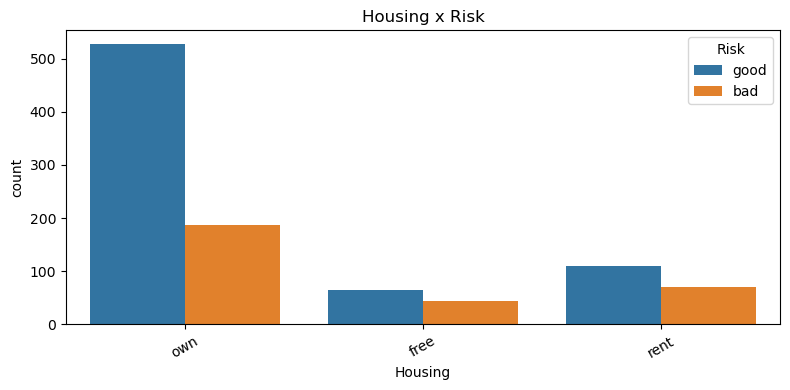


Saving accounts


Risk,bad,good,All
Saving accounts,,,
little,217,386,603
moderate,34,69,103
quite rich,11,52,63
rich,6,42,48
All,268,549,817


Risk,bad,good
Saving accounts,,
little,36.0,64.0
moderate,33.0,67.0
quite rich,17.5,82.5
rich,12.5,87.5


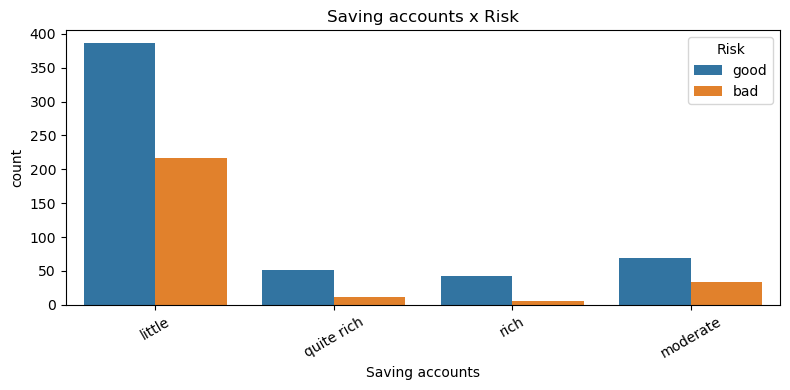


Checking account


Risk,bad,good,All
Checking account,,,
little,135,139,274
moderate,105,164,269
rich,14,49,63
All,254,352,606


Risk,bad,good
Checking account,,
little,49.3,50.7
moderate,39.0,61.0
rich,22.2,77.8


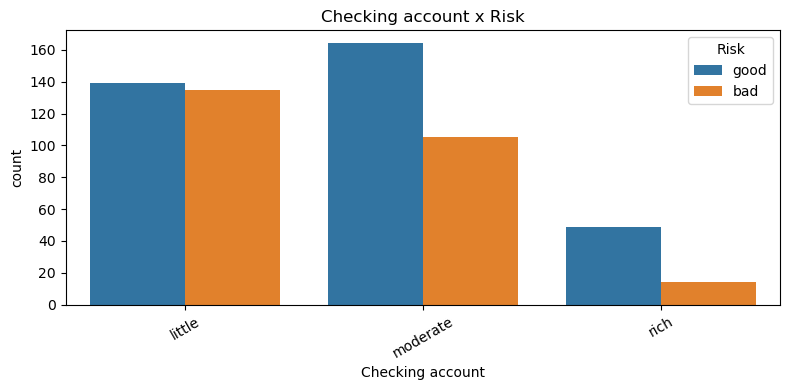


Job


Risk,bad,good,All
Job,,,
0,7,15,22
1,56,144,200
2,186,444,630
3,51,97,148
All,300,700,1000


Risk,bad,good
Job,,
0,31.8,68.2
1,28.0,72.0
2,29.5,70.5
3,34.5,65.5


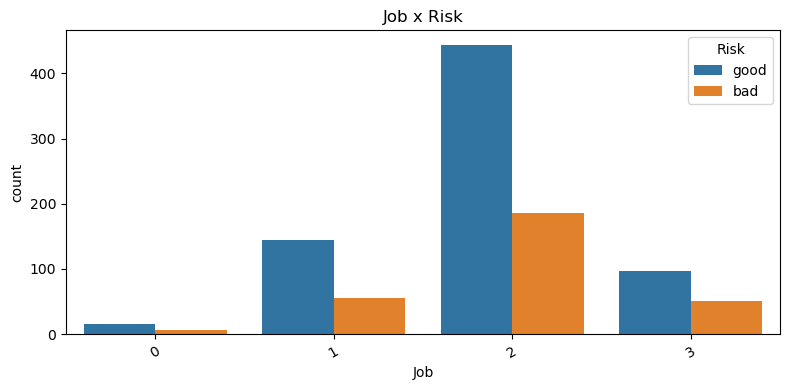


Purpose


Risk,bad,good,All
Purpose,,,
business,34,63,97
car,106,231,337
domestic appliances,4,8,12
education,23,36,59
furniture/equipment,58,123,181
radio/TV,62,218,280
repairs,8,14,22
vacation/others,5,7,12
All,300,700,1000


Risk,bad,good
Purpose,,
business,35.1,64.9
car,31.5,68.5
domestic appliances,33.3,66.7
education,39.0,61.0
furniture/equipment,32.0,68.0
radio/TV,22.1,77.9
repairs,36.4,63.6
vacation/others,41.7,58.3


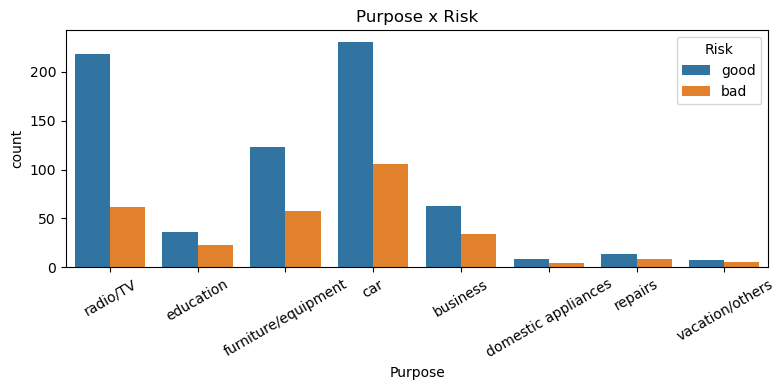

In [33]:
categorical_features = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Job",
    "Purpose"
]

for feature in categorical_features:

    # Tabela de frequências
    print(f"\n{'='*70}")
    print(f"{feature}")
    print(f"{'='*70}")

    display(
        pd.crosstab(
            df[feature],
            df["Risk"],
            margins=True
        )
    )

    # Percentual por categoria

    display(
        pd.crosstab(
            df[feature],
            df["Risk"],
            normalize="index"
        ).round(3) * 100
    )

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=feature,
        hue="Risk"
    )

    plt.title(f"{feature} x Risk")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

- Saving accounts apresentou maior relação com risco de crédito.
- Housing também mostrou diferenças relevantes entre os grupos.
- Sex apresentou baixa capacidade de separação entre as classes.
  
Todas as variáveis serão mantidas para a modelagem


Checking account


Risk,bad,good,All
Checking account,,,
little,135,139,274
moderate,105,164,269
rich,14,49,63
All,254,352,606


Risk,bad,good
Checking account,,
little,49.3,50.7
moderate,39.0,61.0
rich,22.2,77.8


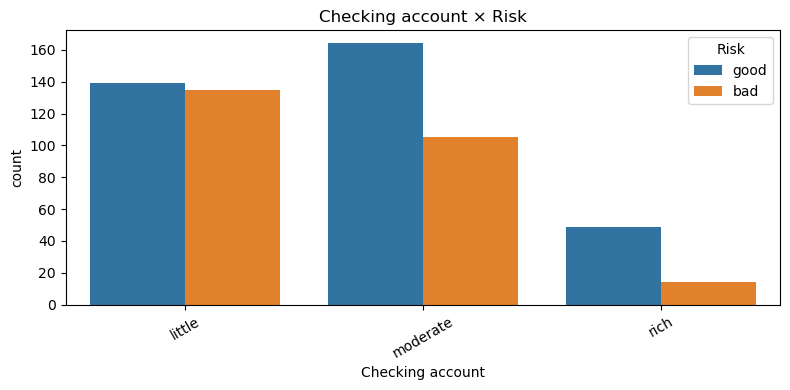


Job


Risk,bad,good,All
Job,,,
0,7,15,22
1,56,144,200
2,186,444,630
3,51,97,148
All,300,700,1000


Risk,bad,good
Job,,
0,31.8,68.2
1,28.0,72.0
2,29.5,70.5
3,34.5,65.5


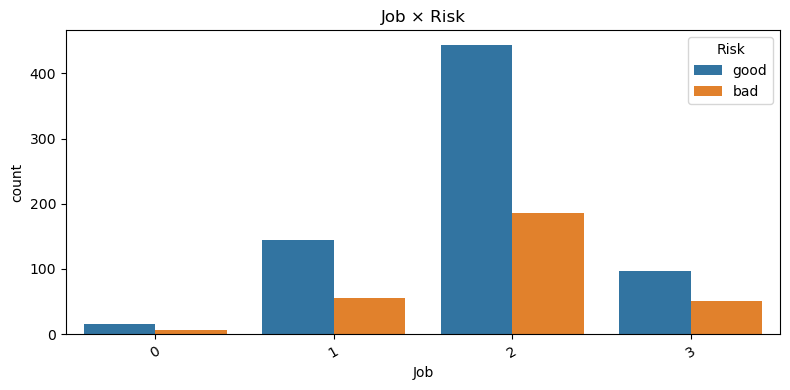


Purpose


Risk,bad,good,All
Purpose,,,
business,34,63,97
car,106,231,337
domestic appliances,4,8,12
education,23,36,59
furniture/equipment,58,123,181
radio/TV,62,218,280
repairs,8,14,22
vacation/others,5,7,12
All,300,700,1000


Risk,bad,good
Purpose,,
business,35.1,64.9
car,31.5,68.5
domestic appliances,33.3,66.7
education,39.0,61.0
furniture/equipment,32.0,68.0
radio/TV,22.1,77.9
repairs,36.4,63.6
vacation/others,41.7,58.3


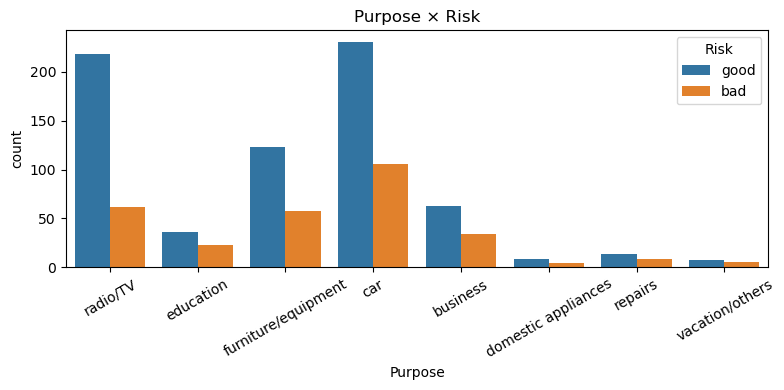

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_features = [
    "Checking account",
    "Job",
    "Purpose"
]

for feature in categorical_features:

    print(f"\n{'='*70}")
    print(feature)
    print(f"{'='*70}")

    # Frequência absoluta
    freq = pd.crosstab(df[feature], df["Risk"], margins=True)
    display(freq)

    # Frequência relativa (%)
    perc = (
        pd.crosstab(df[feature], df["Risk"], normalize="index")
        .mul(100)
        .round(1)
    )
    display(perc)

    # Gráfico de contagem
    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=feature,
        hue="Risk"
    )

    plt.title(f"{feature} × Risk")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

- Checking account apresentou maior relação com risco de crédito.
- Purpose mostrou diferenças relevantes entre categorias.
- Job apresentou menor poder preditivo isolado.
    
Todas as variáveis serão mantidas para a Random Forest avaliar sua contribuição conjunta.